# Holiday Planner - Weather Analysis

This notebook uses the Open-Meteo API to collect and compare weather data for multiple holiday destinations.

The aim is to support destination recommendations based on:
- Latitude and longitude
- Country
- Maximum temperature
- Humidity
- Cloudiness
- Wind speed

## Imports

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## Destinations

In [2]:
destinations = [
    "Berlin, Germany",
    "Tulum, Mexico",
    "Kyoto, Japan",
    "Marrakech, Morocco",
    "Queenstown, New Zealand",
    "Rio de Janeiro, Brazil",
    "Reykjavik, Iceland",
    "Cape Town, South Africa",
    "Ubud, Indonesia",
    "Banff, Canada"]

destinations

['Berlin, Germany',
 'Tulum, Mexico',
 'Kyoto, Japan',
 'Marrakech, Morocco',
 'Queenstown, New Zealand',
 'Rio de Janeiro, Brazil',
 'Reykjavik, Iceland',
 'Cape Town, South Africa',
 'Ubud, Indonesia',
 'Banff, Canada']

In [3]:
def get_location(place_name):
    url = "https://geocoding-api.open-meteo.com/v1/search"
    
    params = {
        "name": place_name,
        "count": 1,
        "language": "en",
        "format": "json"}
    
    response = requests.get(url, params=params)
    data = response.json()
    
    if "results" in data and len(data["results"]) > 0:
        result = data["results"][0]
        
        return {
            "destination": place_name,
            "latitude": result.get("latitude"),
            "longitude": result.get("longitude"),
            "country": result.get("country")}
    else:
        return None

In [4]:
get_location("Kyoto, Japan")

{'destination': 'Kyoto, Japan',
 'latitude': 35.02107,
 'longitude': 135.75385,
 'country': 'Japan'}

In [5]:
def get_weather(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "relative_humidity_2m,cloud_cover,wind_speed_10m",
        "daily": "temperature_2m_max,wind_speed_10m_max",
        "timezone": "auto",
        "forecast_days": 7}
    
    response = requests.get(url, params=params)
    data = response.json()
    
    daily_max_temps = data["daily"]["temperature_2m_max"]
    daily_max_winds = data["daily"]["wind_speed_10m_max"]
    
    return {
        "avg_max_temp_7_days": sum(daily_max_temps) / len(daily_max_temps),
        "current_humidity": data["current"].get("relative_humidity_2m"),
        "current_cloudiness": data["current"].get("cloud_cover"),
        "current_wind_speed": data["current"].get("wind_speed_10m"),
        "avg_max_wind_7_days": sum(daily_max_winds) / len(daily_max_winds)}

In [6]:
test_location = get_location("Kyoto, Japan")
get_weather(test_location["latitude"], test_location["longitude"])

{'avg_max_temp_7_days': 19.328571428571426,
 'current_humidity': 41,
 'current_cloudiness': 100,
 'current_wind_speed': 1.3,
 'avg_max_wind_7_days': 12.799999999999999}

In [7]:
results = []

for destination in destinations:
    location_data = get_location(destination)
    
    if location_data is not None:
        weather_data = get_weather(location_data["latitude"], location_data["longitude"])
        combined_data = {**location_data, **weather_data}
        results.append(combined_data)

df_weather = pd.DataFrame(results)
df_weather

,destination,latitude,longitude,country,avg_max_temp_7_days,current_humidity,current_cloudiness,current_wind_speed,avg_max_wind_7_days
0,"Berlin, Germany",52.52437,13.41053,Germany,14.314286,34,0,13.8,14.528571
1,"Tulum, Mexico",20.21173,-87.46325,Mexico,32.157143,97,68,3.2,13.742857
2,"Kyoto, Japan",35.02107,135.75385,Japan,19.328571,41,100,1.3,12.800000
3,"Marrakech, Morocco",31.63416,-7.99994,Morocco,27.242857,56,29,6.9,10.700000
4,"Rio de Janeiro, Brazil",-22.90642,-43.18223,Brazil,30.785714,88,16,1.5,9.800000
5,"Reykjavik, Iceland",64.13548,-21.89541,Iceland,8.414286,88,100,8.3,28.071429
6,"Cape Town, South Africa",-33.92584,18.42322,South Africa,18.242857,60,11,23.5,24.071429
7,"Ubud, Indonesia",-8.50980,115.26540,Indonesia,29.671429,95,100,1.1,10.157143
8,"Banff, Canada",51.17622,-115.56982,Canada,6.071429,70,100,5.1,11.285714


In [8]:
df_weather = df_weather.round(2)
df_weather

,destination,latitude,longitude,country,avg_max_temp_7_days,current_humidity,current_cloudiness,current_wind_speed,avg_max_wind_7_days
0,"Berlin, Germany",52.52,13.41,Germany,14.31,34,0,13.8,14.53
1,"Tulum, Mexico",20.21,-87.46,Mexico,32.16,97,68,3.2,13.74
2,"Kyoto, Japan",35.02,135.75,Japan,19.33,41,100,1.3,12.80
3,"Marrakech, Morocco",31.63,-8.00,Morocco,27.24,56,29,6.9,10.70
4,"Rio de Janeiro, Brazil",-22.91,-43.18,Brazil,30.79,88,16,1.5,9.80
5,"Reykjavik, Iceland",64.14,-21.90,Iceland,8.41,88,100,8.3,28.07
6,"Cape Town, South Africa",-33.93,18.42,South Africa,18.24,60,11,23.5,24.07
7,"Ubud, Indonesia",-8.51,115.27,Indonesia,29.67,95,100,1.1,10.16
8,"Banff, Canada",51.18,-115.57,Canada,6.07,70,100,5.1,11.29


In [9]:
df_weather.sort_values(by="avg_max_temp_7_days", ascending=False)

,destination,latitude,longitude,country,avg_max_temp_7_days,current_humidity,current_cloudiness,current_wind_speed,avg_max_wind_7_days
1,"Tulum, Mexico",20.21,-87.46,Mexico,32.16,97,68,3.2,13.74
4,"Rio de Janeiro, Brazil",-22.91,-43.18,Brazil,30.79,88,16,1.5,9.80
7,"Ubud, Indonesia",-8.51,115.27,Indonesia,29.67,95,100,1.1,10.16
3,"Marrakech, Morocco",31.63,-8.00,Morocco,27.24,56,29,6.9,10.70
2,"Kyoto, Japan",35.02,135.75,Japan,19.33,41,100,1.3,12.80
6,"Cape Town, South Africa",-33.93,18.42,South Africa,18.24,60,11,23.5,24.07
0,"Berlin, Germany",52.52,13.41,Germany,14.31,34,0,13.8,14.53
5,"Reykjavik, Iceland",64.14,-21.90,Iceland,8.41,88,100,8.3,28.07
8,"Banff, Canada",51.18,-115.57,Canada,6.07,70,100,5.1,11.29


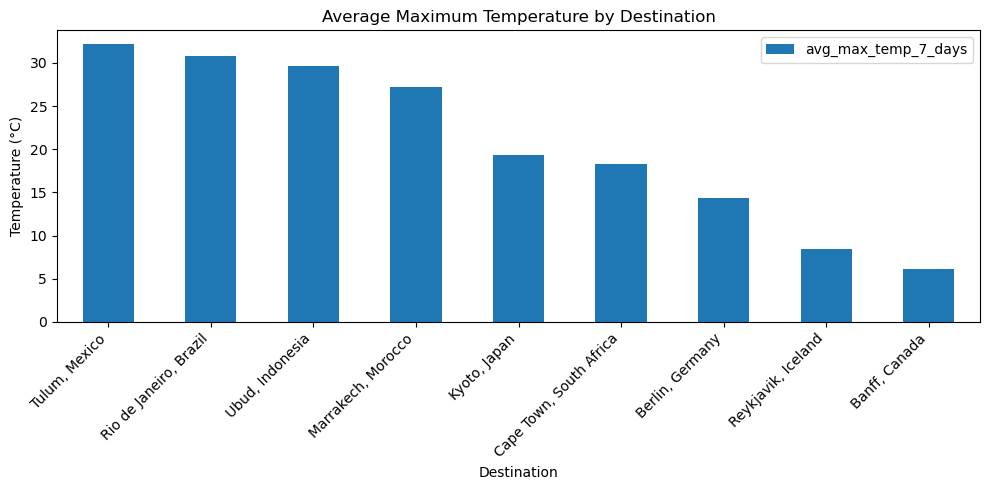

In [10]:
df_weather.sort_values("avg_max_temp_7_days", ascending=False).plot(
    x="destination",
    y="avg_max_temp_7_days",
    kind="bar",
    figsize=(10, 5))

plt.title("Average Maximum Temperature by Destination")
plt.xlabel("Destination")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Initial Findings

The destinations show clear differences in average maximum temperature, humidity, cloudiness, and wind speed.

This provides a first comparison of weather suitability across the selected holiday options and can support further recommendation when combined with cost and location-based data.